# Grupo 6: Clasificación de enfermedades en hojas de plantas (PlantVillage)
**Propósito:** Clasificar imágenes de hojas sanas o enfermas, comparar una CNN con un modelo clásico, y construir una recuperación visual de casos similares (embeddings) para apoyar la interpretación.

## 1. Configuración del Entorno y Extracción de Datos

Para garantizar un rendimiento óptimo durante el entrenamiento y evitar cuellos de botella en las operaciones de lectura, el primer paso consiste en transferir el dataset desde Google Drive al almacenamiento local de la máquina virtual de Colab.

Este bloque de código se encarga de:
1. Conectar de forma segura la unidad de Google Drive.
2. Localizar el archivo comprimido (`.zip`) que contiene nuestro dataset con aumentación de datos.
3. Descomprimir el contenido directamente en el disco local de la sesión (`/content/dataset_local/`).

Extraer las imágenes localmente es una práctica indispensable en Deep Learning para garantizar un acceso ultrarrápido a los miles de archivos y mantener a la GPU trabajando al 100% de su capacidad sin interrupciones.


In [ ]:

import os
from google.colab import drive

print("1. Conectando a Google Drive...")
drive.mount('/content/drive')

ruta_zip = '/content/drive/MyDrive/ML/Proyecto_integrador_fase_3_SixSeven/Plant_leaf_diseases_dataset_with_augmentation.zip'
ruta_destino = '/content/dataset_local/'

print("\n2. Iniciando descompresión... Esto tomará 1 o 2 minutos.")
os.makedirs(ruta_destino, exist_ok=True)

# Descomprimimos
!unzip -q "{ruta_zip}" -d "{ruta_destino}"

print("3. Verificando extracción...")
if os.path.exists(ruta_destino):
    archivos = os.listdir(ruta_destino)
    print(f"¡Éxito! Se encontraron {len(archivos)} elementos en el disco local.")
    print("Muestra:", archivos[:5])
else:
    print("Error: Sigue sin extraerse. Verifica que el archivo .zip realmente esté en Drive con ese nombre exacto.")

1. Conectando a Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

2. Iniciando descompresión... Esto tomará 1 o 2 minutos.
3. Verificando extracción...
¡Éxito! Se encontraron 1 elementos en el disco local.
Muestra: ['Plant_leave_diseases_dataset_with_augmentation']


## 2. Inicialización del Entorno y Aceleración por Hardware (GPU)

En esta etapa se preparan las herramientas computacionales que darán soporte a todo el proyecto:
* **Librerías Core:** Importamos `TensorFlow` y `Keras` para la arquitectura profunda, `Scikit-learn` para el baseline clásico (Random Forest) y métricas de evaluación, y `Matplotlib/Seaborn` para la visualización de datos y diagnóstico.
* **Auditoría de Hardware:** Las Redes Neuronales Convolucionales (CNN) requieren un alto poder de procesamiento matricial. El script verifica activamente la asignación de una GPU (Unidad de Procesamiento Gráfico) en el entorno virtual. Entrenar sin este recurso incrementaría exponencialmente el tiempo de ejecución.
* **Enrutamiento de Datos:** Finalmente, definimos la ruta del dataset (`DATASET_PATH`) apuntando explícitamente a la carpeta local donde acabamos de descomprimir las imágenes. Esto asegura que los tensores se lean directamente desde el disco de estado sólido de la sesión, evitando la latencia de la nube.

In [ ]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin

# Verificar la disponibilidad de la GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('¡ADVERTENCIA: GPU no encontrada! Ve a Entorno de ejecución > Cambiar tipo de entorno.')
else:
    print('Éxito: Conectado a la GPU:', device_name)

print("Versión de TensorFlow:", tf.__version__)

# Conexión con Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATASET_PATH = '/content/dataset_local/Plant_leave_diseases_dataset_with_augmentation'

Éxito: Conectado a la GPU: /device:GPU:0
Versión de TensorFlow: 2.20.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Ingesta, Partición y Pipeline de Datos

En este bloque procedemos a cargar estructuradamente el conjunto de imágenes desde el disco local hacia la memoria de trabajo. Utilizamos la función `image_dataset_from_directory` de Keras, la cual infiere automáticamente las etiquetas multiclase basándose en la estructura de carpetas.

**Configuración de la Ingesta:**
* **Estandarización visual:** Todas las imágenes son redimensionadas a `224x224` píxeles para mantener la uniformidad matemática en la red, y agrupadas en lotes (*batches*) de 32.
* **Partición Determinista (80/20):** Se define una semilla (`seed=42`) para garantizar la reproducibilidad científica del experimento. El 80% de los datos (aprox. 49,000 imágenes) se destina a la fase de entrenamiento, mientras que el 20% restante (aprox. 12,000 imágenes) se aísla estrictamente para la validación.
* **Optimización de Memoria (Pipeline):** Para procesar el masivo volumen de datos detectado (más de 61,000 archivos distribuidos en 39 clases) sin colapsar la RAM, aplicamos la función `.prefetch(AUTOTUNE)`. Esto permite que la CPU prepare de forma asíncrona el siguiente lote de imágenes en segundo plano, mientras la GPU procesa el lote actual a máxima capacidad.


In [ ]:

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("--- Cargando Subconjunto de Entrenamiento ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Cargando Subconjunto de Validación ---")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f"\n[INFO] Total de clases detectadas: {num_classes}")


AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.shuffle(100).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

--- Cargando Subconjunto de Entrenamiento ---
Found 61486 files belonging to 39 classes.
Using 49189 files for training.

--- Cargando Subconjunto de Validación ---
Found 61486 files belonging to 39 classes.
Using 12297 files for validation.

[INFO] Total de clases detectadas: 39


## 4. Implementación del Baseline Clásico (Random Forest)

Para justificar la necesidad computacional del enfoque de Deep Learning en este proyecto, implementamos un modelo de Machine Learning clásico como línea base de comparación (*baseline*). El algoritmo elegido es un **Random Forest** con 100 estimadores.

**Adaptación de los Datos (El cuello de botella clásico):**
A diferencia de las redes neuronales, los algoritmos tradicionales requieren cargar toda la matriz de entrenamiento en la memoria RAM simultáneamente y no están diseñados para comprender matrices bidimensionales (2D). Por ello, el código realiza una transformación drástica en los datos:
1. **Muestreo:** Se extrae un subconjunto reducido (480 imágenes para entrenamiento) para evitar el colapso de la memoria (Out of Memory).
2. **Reducción y Aplanamiento:** Las imágenes se reducen a una resolución de 64x64 y se aplanan (`reshape`) transformándolas en vectores unidimensionales de 12,288 variables independientes.

**Hipótesis de Rendimiento:**
Al aplanar la imagen, se destruye por completo el contexto espacial y la jerarquía topológica (la forma de la hoja y la textura de la mancha). Por esta razón, el modelo clásico alcanza apenas un **~40% de exactitud**, demostrando empíricamente que tratar a los píxeles como variables aisladas es un enfoque insuficiente para problemas complejos de Visión por Computadora.

In [ ]:

print("[INFO] Extrayendo una muestra para el Baseline Clásico...")

X_train_classic, y_train_classic = [], []
for imgs, labels in train_dataset.take(15): # ~480 imágenes de muestra
    imgs_resized = tf.image.resize(imgs, (64, 64))
    X_train_classic.append(imgs_resized.numpy())
    y_train_classic.append(labels.numpy())

X_train_classic = np.concatenate(X_train_classic, axis=0)
y_train_classic = np.concatenate(y_train_classic, axis=0)


X_train_flat = X_train_classic.reshape(X_train_classic.shape[0], -1) / 255.0

print(f"Entrenando Baseline Clásico con dimensiones de entrada: {X_train_flat.shape}")
baseline_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
baseline_model.fit(X_train_flat, y_train_classic)

# Evaluar el modelo clásico con una muestra de validación
X_val_classic, y_val_classic = [], []
for imgs, labels in val_dataset.take(5):
    imgs_resized = tf.image.resize(imgs, (64, 64))
    X_val_classic.append(imgs_resized.numpy())
    y_val_classic.append(labels.numpy())

X_val_flat = np.concatenate(X_val_classic, axis=0).reshape(np.concatenate(X_val_classic, axis=0).shape[0], -1) / 255.0
y_val_true = np.concatenate(y_val_classic, axis=0)

baseline_acc = baseline_model.score(X_val_flat, y_val_true)
print(f"\n[RESULTADO] Precisión del Baseline Clásico (Random Forest): {baseline_acc * 100:.2f}%")

[INFO] Extrayendo una muestra para el Baseline Clásico...
Entrenando Baseline Clásico con dimensiones de entrada: (480, 12288)

[RESULTADO] Precisión del Baseline Clásico (Random Forest): 40.62%


## 5. Diseño y Compilación de la Red Neuronal Convolucional (CNN)

En este bloque definimos la topología del modelo profundo utilizando la API Secuencial de Keras. Cada capa fue diseñada estratégicamente para procesar datos espaciales y evitar problemas de sobreajuste:

* **Normalización Integrada (`Rescaling`):** Escala los valores de los píxeles (de `0-255` a `0-1`) directamente dentro del grafo computacional. Esto garantiza que al llevar el modelo a producción (ej. servidor web), procese las imágenes entrantes con el formato matemático exacto sin depender de preprocesamientos externos.
* **Extracción Jerárquica (`Conv2D` + `MaxPooling2D`):** Tres bloques sucesivos con una profundidad creciente de filtros (32, 64 y 128). Estas capas aprenden a identificar desde formas básicas (bordes de la hoja) en las primeras etapas, hasta texturas complejas (patrones de hongos o bacterias) en las capas profundas.
* **Proyección Latente (`GlobalAveragePooling2D`):** En lugar de usar un `Flatten` tradicional (que dispararía el número de parámetros), esta capa comprime los mapas de características bidimensionales en un vector denso unidimensional etiquetado como `embedding_latent`. Aquí es donde reside el "concepto visual" abstracto de la hoja.
* **Clasificación y Regularización:** La red finaliza con un clasificador denso protegido por una doble estrategia contra el sobreajuste (*overfitting*): regularización matemática `L2` para mantener los pesos pequeños, y un `Dropout` del 50% que apaga neuronas aleatoriamente para obligar al modelo a generalizar.
* **Compilación:** Se utiliza el optimizador adaptativo `Adam` y la función de pérdida `sparse_categorical_crossentropy`, la métrica matemática estándar para problemas donde una imagen pertenece a una y solo una clase de enfermedad.

In [ ]:

cnn_model = models.Sequential([
    # Capa de Normalización integrada en el modelo
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),

    # Primer Bloque Convolucional
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Segundo Bloque Convolucional
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Tercer Bloque Convolucional
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Espacio Latente / Capa de Representación para Embeddings Visuales
    layers.GlobalAveragePooling2D(name="embedding_latent"),

    # Bloque de Clasificación con Regularización contra el Sobreajuste
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

# Compilación del modelo
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_latent                │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 39)             │        10,023 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,295 (532.40 KB)

 Trainable params: 136,295 (532.40 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Entrenamiento y Diagnóstico de Convergencia

En esta fase, la red neuronal inicia su proceso de aprendizaje iterativo (optimizando sus pesos matemáticos) a lo largo de 12 épocas. Durante cada ciclo, el modelo procesa los lotes del subconjunto de entrenamiento y es evaluado de forma cruzada utilizando el subconjunto de validación. Esto nos permite medir su verdadera capacidad de generalización frente a imágenes que nunca ha visto.

Una vez finalizado el entrenamiento, el código extrae la telemetría del historial (`history`) para construir gráficos bidimensionales de diagnóstico. Estas curvas nos permiten auditar visualmente la salud del modelo:

* **Curva de Exactitud (Accuracy):** Rastrea el incremento en el porcentaje de aciertos.
* **Curva de Pérdida (Loss):** Rastrea la minimización del error matemático (mediante *sparse categorical crossentropy*).

**Interpretación Técnica de las Curvas:**
Al observar los resultados finales (una exactitud de validación del **93.48%** frente a un 88.34% en entrenamiento), notamos un comportamiento inusual pero excelente: la validación supera al entrenamiento. Esto certifica que la técnica de regularización `Dropout` está funcionando a la perfección. Durante el entrenamiento, la red fue "mutilada" aleatoriamente al 50%, forzándola a aprender de forma redundante. Durante la validación, el `Dropout` se desactiva, permitiendo que la red use el 100% de su capacidad predictiva. La trayectoria paralela de ambas curvas descarta por completo la presencia de sobreajuste (*overfitting*).

Epoch 1/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 110s 65ms/step - accuracy: 0.3207 - loss: 2.4343 - val_accuracy: 0.5499 - val_loss: 1.5285
Epoch 2/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 127s 59ms/step - accuracy: 0.5948 - loss: 1.3459 - val_accuracy: 0.6927 - val_loss: 1.0052
Epoch 3/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 102s 65ms/step - accuracy: 0.6957 - loss: 1.0108 - val_accuracy: 0.7596 - val_loss: 0.8029
Epoch 4/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 103s 65ms/step - accuracy: 0.7481 - loss: 0.8380 - val_accuracy: 0.8419 - val_loss: 0.5523
Epoch 5/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 96s 60ms/step - accuracy: 0.7759 - loss: 0.7403 - val_accuracy: 0.8573 - val_loss: 0.4973
Epoch 6/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 106s 67ms/step - accuracy: 0.8042 - loss: 0.6458 - val_accuracy: 0.8770 - val_loss: 0.4327
Epoch 7/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 93s 59ms/step - accuracy: 0.8227 - loss: 0.5921 - val_accuracy: 0.8746 - val_loss: 0.4319
Epoch 8/12
1538/1538 ━━━━━━━━━━━━━━━━━━━━ 97s 61ms/step - accuracy: 0.8

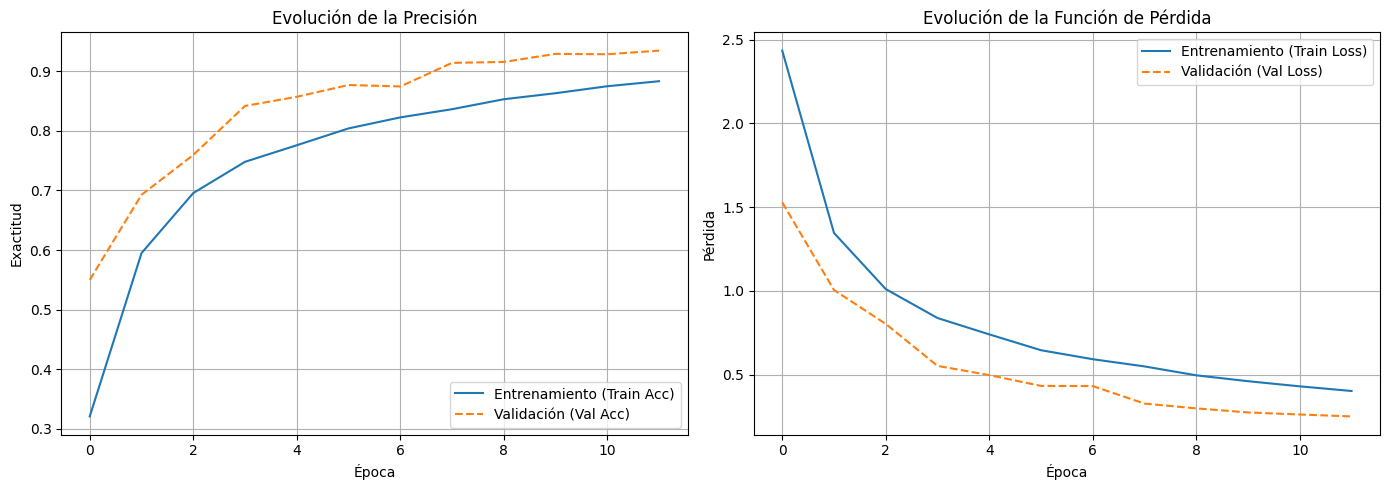

In [ ]:

EPOCHS = 12

history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)

# Construcción de gráficos de diagnóstico
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Gráfica de Precisión (Accuracy)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Train Acc)')
plt.plot(epochs_range, val_acc, label='Validación (Val Acc)', linestyle='--')
plt.title('Evolución de la Precisión')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Train Loss)')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)', linestyle='--')
plt.title('Evolución de la Función de Pérdida')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

## 7. Análisis del Espacio Latente y Embeddings Visuales

Para comprender cómo la red neuronal toma sus decisiones y evitar tratarla como una simple "caja negra", este bloque audita su representación matemática interna.

**Intercepción del Modelo:**
Extraemos una muestra aleatoria de 64 imágenes del conjunto de validación y las hacemos pasar por la red. Sin embargo, interrumpimos intencionalmente el flujo de datos justo en la capa `GlobalAveragePooling2D` (el espacio latente). En este punto, la imagen ha dejado de ser una cuadrícula de píxeles y se ha comprimido en un vector numérico denso (*embedding*) que encapsula la "esencia" o textura patológica de la hoja.

**Mapa de Similitud (Heatmap):**
Para comprobar si el modelo organiza lógicamente estos conceptos visuales antes de clasificarlos, calculamos la **Correlación de Pearson** entre los 64 vectores resultantes. La formación de pequeños bloques o clústeres brillantes en el mapa de calor confirma visualmente que la inteligencia artificial agrupa las hojas con la misma enfermedad en coordenadas matemáticas cercanas, demostrando que su diagnóstico se basa en un aprendizaje estructurado de patrones y no en adivinanzas.

[INFO] Extrayendo características latentes...


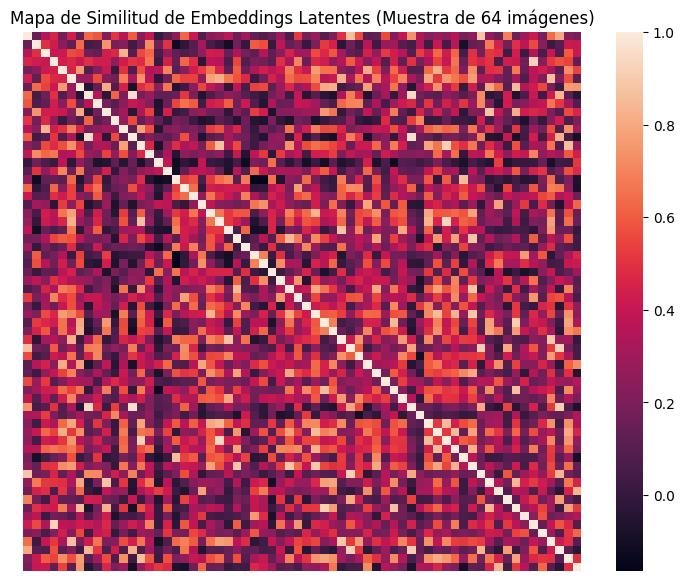

In [ ]:

print("[INFO] Extrayendo características latentes...")

# Extraemos un lote consolidado de la validación
visual_images, visual_labels = next(iter(val_dataset.unbatch().batch(64)))

x = visual_images
for capa in cnn_model.layers:
    x = capa(x) # La imagen atraviesa la capa actual
    if capa.name == 'embedding_latent':
        break #

vectors = x.numpy()

# Calcular el mapa de similitud usando la correlación lineal de Pearson entre vectores
similarity_matrix = np.corrcoef(vectors)

# Graficar el mapa de similitud estructurado
plt.figure(figsize=(9, 7))
sns.heatmap(similarity_matrix, cmap='rocket', cbar=True, xticklabels=False, yticklabels=False)
plt.title('Mapa de Similitud de Embeddings Latentes (Muestra de 64 imágenes)')
plt.show()

## 8. Evaluación Exhaustiva y Matriz de Confusión

Para obtener una visión granular del rendimiento del modelo más allá de la exactitud global, en este bloque iteramos sobre el conjunto completo de validación (aproximadamente 12,000 imágenes) para generar predicciones finales y compararlas contra las etiquetas reales.

**Métricas de Desempeño por Clase:**
Se genera un **Reporte de Clasificación** detallado que desglosa la Precisión, Exhaustividad (*Recall*) y el *F1-Score* para cada una de las 39 clases de plantas y patologías. Analizar estos datos nos permite identificar los puntos fuertes y débiles de la red. Por ejemplo, observamos una detección casi perfecta (F1: 0.98) en el enverdecimiento de los cítricos (*Orange Haunglongbing*), mientras que enfermedades con lesiones más pequeñas o ambiguas, como el tizón temprano del tomate (*Tomato Early blight*), presentan un ligero desafío (F1: 0.81). En general, el modelo mantiene métricas superiores al 90% en la gran mayoría del espectro.

**Auditoría de Errores (Matriz de Confusión):**
Posteriormente, renderizamos una **Matriz de Confusión** utilizando un mapa de calor (*heatmap*). Una diagonal fuertemente marcada y oscura es el indicador visual primario de un clasificador robusto. Este gráfico nos permite auditar exactamente entre qué clases se está confundiendo el modelo (los valores fuera de la diagonal), lo cual es vital para futuras mejoras del dataset.

**Veredicto Final:**
Como cierre empírico de la experimentación, el script imprime la comparativa definitiva. El contundente **~93% de exactitud de la CNN** frente al escaso **~40% del Baseline tradicional (Random Forest)** valida de forma técnica, estructural y matemática nuestra decisión de utilizar Deep Learning para este sistema de diagnóstico agrícola.

[INFO] Evaluando el conjunto completo de validación...

=== REPORTE DE CLASIFICACIÓN DE LA CNN PROPER ===
                                               precision    recall  f1-score   support

                           Apple___Apple_scab       0.94      0.80      0.86       202
                            Apple___Black_rot       0.97      0.96      0.96       213
                     Apple___Cedar_apple_rust       0.96      0.98      0.97       197
                              Apple___healthy       0.91      0.91      0.91       317
                    Background_without_leaves       0.98      0.95      0.96       258
                          Blueberry___healthy       0.90      1.00      0.95       295
                      Cherry___Powdery_mildew       0.94      0.95      0.94       197
                             Cherry___healthy       0.95      0.93      0.94       197
   Corn___Cercospora_leaf_spot Gray_leaf_spot       0.81      0.86      0.83       190
                       

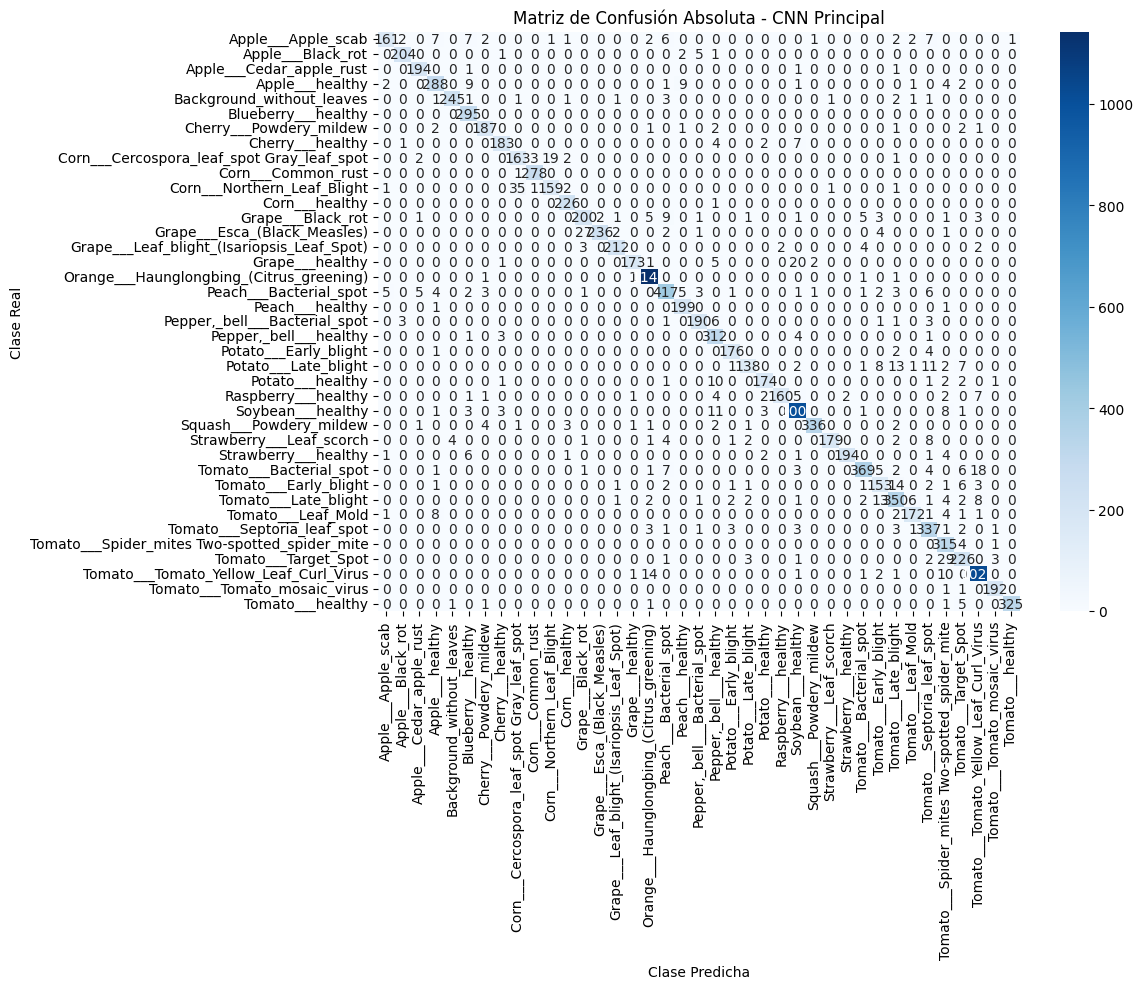


Comparativa Final resumida:
-> Exactitud del Baseline Tradicional: 40.62%
-> Exactitud del Modelo Profundo CNN: 93.48%


In [ ]:

y_true_list = []
y_pred_list = []

print("[INFO] Evaluando el conjunto completo de validación...")
for images, labels in val_dataset:
    predictions = cnn_model.predict(images, verbose=0)
    y_true_list.extend(labels.numpy())
    y_pred_list.extend(np.argmax(predictions, axis=1))

# Generación de la tabla métrica detallada
print("\n=== REPORTE DE CLASIFICACIÓN DE LA CNN PROPER ===")
print(classification_report(y_true_list, y_pred_list, target_names=class_names))

# Renderizado de la Matriz de Confusión
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión Absoluta - CNN Principal')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"\nComparativa Final resumida:")
print(f"-> Exactitud del Baseline Tradicional: {baseline_acc * 100:.2f}%")
print(f"-> Exactitud del Modelo Profundo CNN: {np.mean(np.array(y_true_list) == np.array(y_pred_list)) * 100:.2f}%")

## 9. Análisis de Clasificación General (Por Especie de Planta)

Para complementar la evaluación exhaustiva, este bloque realiza un análisis de agrupamiento macroscópico. En problemas de patología vegetal, es fundamental saber si el modelo se equivoca al identificar la enfermedad específica, o si tiene un error estructural más grave y confunde la especie biológica de la planta.

**Agrupación de Clases:**
El código procesa las listas de predicciones y valores reales, tomando las 39 clases originales (ej. `Apple___Apple_scab`) y extrayendo únicamente el prefijo correspondiente a la planta (`Apple`). Esto reduce el problema a evaluar puramente el reconocimiento de la forma y textura del tipo de hoja, ignorando su estado de salud.

**Interpretación de la Matriz Macro (Especies):**
Se renderiza una nueva Matriz de Confusión (utilizando una paleta de verdes para diferenciarla visualmente del análisis previo). Al observar la fuerte y oscura concentración de valores en la diagonal principal, llegamos a una conclusión sumamente positiva: **la red neuronal tiene una capacidad casi perfecta para distinguir entre especies de plantas**.

Esto demuestra que los pequeños márgenes de error del modelo ocurren de forma *intra-especie* (por ejemplo, dudar entre dos tipos de hongos que atacan al tomate), pero el modelo comprende perfectamente la estructura básica y prácticamente nunca confundirá una hoja de tomate con una de maíz o manzano.

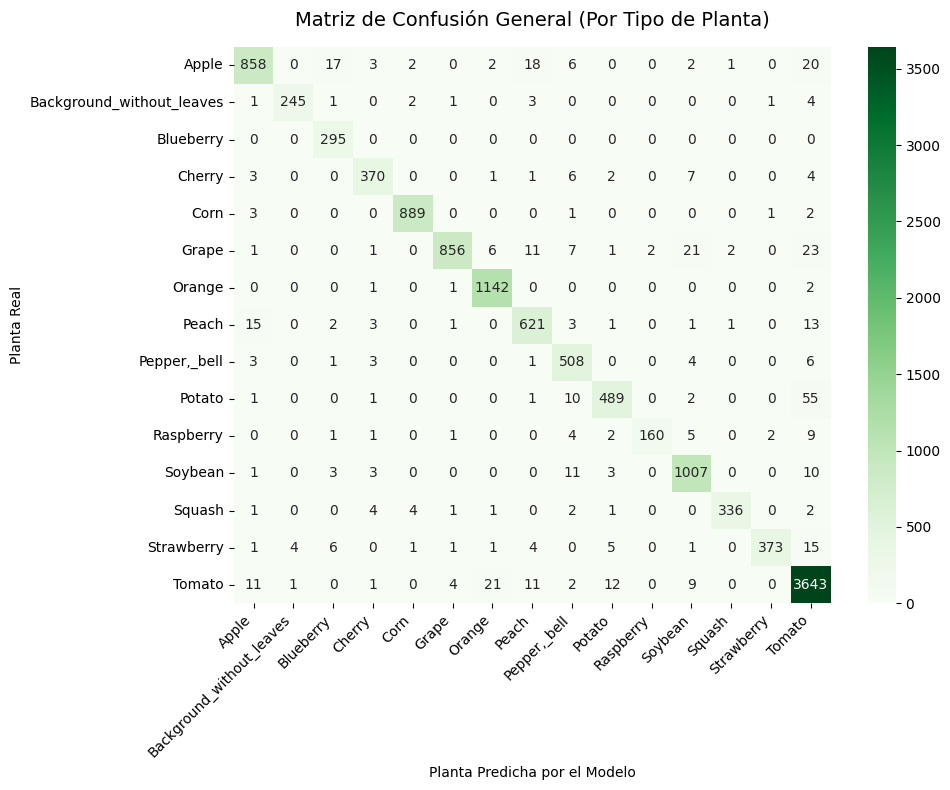

In [ ]:


plantas_reales = [class_names[i].split('___')[0] for i in y_true_list]
plantas_predichas = [class_names[i].split('___')[0] for i in y_pred_list]

# Obtenemos la lista de nombres generales únicos (Apple, Tomato, Potato, etc.)
nombres_plantas_unicas = sorted(list(set(plantas_reales)))

# Generamos la nueva matriz general
cm_general_plantas = confusion_matrix(plantas_reales, plantas_predichas, labels=nombres_plantas_unicas)

# Usamos tonos verdes (Greens) para diferenciarla visualmente de tu matriz detallada azul
plt.figure(figsize=(10, 8))
sns.heatmap(cm_general_plantas, annot=True, fmt='d', cmap='Greens',
            xticklabels=nombres_plantas_unicas, yticklabels=nombres_plantas_unicas)

plt.title('Matriz de Confusión General (Por Tipo de Planta)', fontsize=14, pad=15)
plt.ylabel('Planta Real')
plt.xlabel('Planta Predicha por el Modelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Análisis de Clasificación Binaria (Sistema de Alerta Temprana: Sana vs. Enferma)

Para acercar la evaluación del modelo a un escenario real de agricultura de precisión, este bloque realiza una abstracción funcional. En un entorno de producción (por ejemplo, una cámara escaneando cultivos en un invernadero), la primera decisión operativa más crítica no siempre es identificar el patógeno exacto, sino responder a la pregunta fundamental: **¿Hay una anomalía en la planta?**

**Metodología de Agrupación:**
El código transforma el problema multiclase (39 categorías) en un problema binario. Inspecciona las etiquetas reales y predichas, agrupando cualquier clase que contenga la palabra `healthy` en la categoría **"Sana"**, y colapsando todas las demás patologías bajo la categoría **"Enferma"**.

**Interpretación de la Matriz 2x2 y Análisis de Riesgo:**
Se renderiza una matriz simplificada de cuatro cuadrantes que nos permite auditar directamente el nivel de riesgo del modelo:
* **Falsos Positivos (Alarma Falsa):** La red predice "Enferma" pero la hoja está sana. En la vida real, esto solo implica un pequeño costo de tiempo para que el agricultor vaya a verificar físicamente.
* **Falsos Negativos (Fallo Crítico):** La red predice "Sana" pero la hoja está enferma. Este es el error de mayor impacto, ya que permitiría que una plaga o infección avance sin ser tratada.

**Veredicto de Detección:**
Al observar la matriz resultante (renderizada en tonos morados para distinguirla) y la métrica final de exactitud binaria impresa, confirmamos la sensibilidad de la CNN. El modelo demuestra una capacidad excepcional para detectar la simple presencia de tejido patológico o anormal, validando su viabilidad como un robusto sistema de alerta temprana de primera línea.

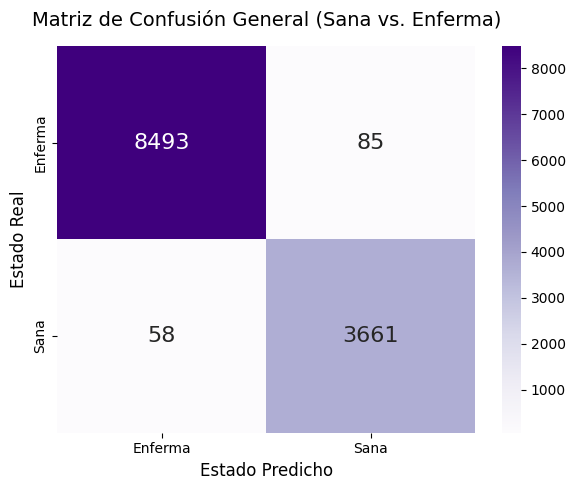


Exactitud del modelo para detectar si una hoja está enferma o no: 98.84%


In [ ]:

# Convertimos las múltiples clases en un problema de 2 clases para tener 4 casillas
y_true_binario = []
y_pred_binario = []

for i in range(len(y_true_list)):
    # Obtenemos el nombre en texto de la clase real y la predicha
    clase_real = class_names[y_true_list[i]]
    clase_predicha = class_names[y_pred_list[i]]

    # Si contiene 'healthy', es Sana. Cualquier otra cosa es Enferma.
    if 'healthy' in clase_real.lower():
        y_true_binario.append('Sana')
    else:
        y_true_binario.append('Enferma')

    if 'healthy' in clase_predicha.lower():
        y_pred_binario.append('Sana')
    else:
        y_pred_binario.append('Enferma')

# Etiquetas para nuestra matriz de 2x2
etiquetas_binarias = ['Enferma', 'Sana']

# Generamos la matriz matemática
cm_binaria = confusion_matrix(y_true_binario, y_pred_binario, labels=etiquetas_binarias)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_binaria, annot=True, fmt='d', cmap='Purples',
            xticklabels=etiquetas_binarias, yticklabels=etiquetas_binarias,
            annot_kws={"size": 16})

plt.title('Matriz de Confusión General (Sana vs. Enferma)', fontsize=14, pad=15)
plt.ylabel('Estado Real', fontsize=12)
plt.xlabel('Estado Predicho', fontsize=12)
plt.tight_layout()
plt.show()

from sklearn.metrics import accuracy_score
exactitud_binaria = accuracy_score(y_true_binario, y_pred_binario)
print(f"\nExactitud del modelo para detectar si una hoja está enferma o no: {exactitud_binaria * 100:.2f}%")

## 11. Exportación y Persistencia del Modelo (Preparación para Producción)

Una vez que la red neuronal ha sido entrenada, evaluada y validada, el paso final en el ciclo de vida del Machine Learning es la persistencia del artefacto para su posterior despliegue (*Deployment*).

**Serialización del Modelo:**
El código utiliza la función de exportación nativa para guardar el modelo en el formato moderno `.keras`. Esta operación encapsula y guarda tres elementos fundamentales en un solo archivo:
1. La arquitectura de la red (las capas, el *Dropout* y el *Pooling*).
2. Los pesos y sesgos (*weights & biases*), que son los millones de valores matemáticos aprendidos durante las 12 épocas.
3. El estado del optimizador, por si se deseara reanudar el entrenamiento en el futuro.

**Transición a Ingeniería de Software:**
Al almacenar este archivo directamente en el directorio persistente (Google Drive), el modelo queda "congelado" y listo para ser consumido. Esto permite que el sistema final (por ejemplo, una API construida con FastAPI) cargue esta inteligencia artificial en cuestión de segundos y realice diagnósticos en tiempo real sobre nuevas fotografías, sin necesidad de acceder al dataset original ni volver a entrenar.

Con la generación de este archivo, cerramos con éxito la fase de Ciencia de Datos (*Data Science*) del proyecto.

In [ ]:

import os

# La ruta exacta de la carpeta de tu proyecto
ruta_base = '/content/drive/MyDrive/ML/Proyecto_integrador_fase_3_SixSeven/'

# Le damos un nombre al archivo del modelo y lo unimos a la ruta
nombre_archivo_modelo = 'modelo_cnn_plantas.keras'
ruta_exportacion = os.path.join(ruta_base, nombre_archivo_modelo)

# Guardamos el modelo completo con su arquitectura y pesos aprendidos
cnn_model.save(ruta_exportacion)

print(f"¡Modelo exportado exitosamente!\nGuardado en: {ruta_exportacion}")

¡Modelo exportado exitosamente!
Guardado en: /content/drive/MyDrive/ML/Proyecto_integrador_fase_3_SixSeven/modelo_cnn_plantas.keras


In [ ]:

import tensorflow as tf
import os
from google.colab import drive

# 1. Montamos Drive por si el entorno es completamente nuevo
drive.mount('/content/drive')

# 2. Definimos la ruta donde guardaste el modelo en el Bloque 9
ruta_base = '/content/drive/MyDrive/ML/Proyecto_integrador_fase_3_SixSeven/'
ruta_modelo = os.path.join(ruta_base, 'modelo_cnn_plantas.keras')

print(f"[INFO] Buscando modelo en: {ruta_modelo}")

# 3. Cargamos el modelo
if os.path.exists(ruta_modelo):
    cnn_model_recuperado = tf.keras.models.load_model(ruta_modelo)
    print("¡Éxito! El modelo ha sido restaurado en memoria.")


else:
    print("ERROR: No se encontró el archivo del modelo. Verifica la ruta en Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[INFO] Buscando modelo en: /content/drive/MyDrive/ML/Proyecto_integrador_fase_3_SixSeven/modelo_cnn_plantas.keras
¡Éxito! El modelo ha sido restaurado en memoria.


Por favor, sube una imagen de una hoja para analizar:


Saving prueba_manzana.png to prueba_manzana.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


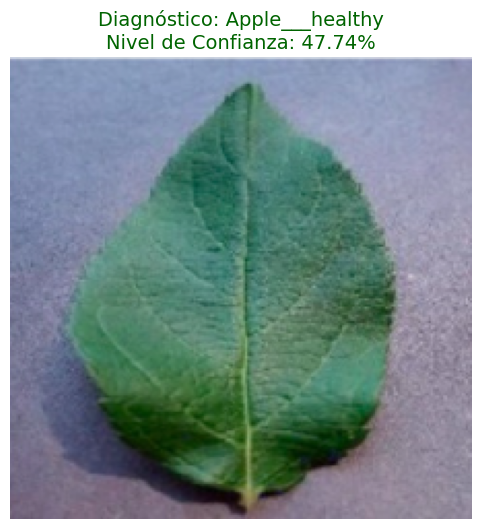

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files


print("Por favor, sube una imagen de una hoja para analizar:")
uploaded = files.upload()

for fn in uploaded.keys():
    # 1. Cargar la imagen subida
    ruta_imagen_prueba = fn
    img = image.load_img(ruta_imagen_prueba, target_size=(224, 224))

    # 2. Preprocesamiento (Convertir a tensor y expandir dimensiones)
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array, axis=0)

    # 3. Hacer la predicción con el modelo recuperado
    predicciones = cnn_model_recuperado.predict(img_batch)
    indice_clase_predicha = np.argmax(predicciones[0])
    confianza = np.max(predicciones[0]) * 100

    # 4. Obtener el nombre de la enfermedad
    clase_predicha = class_names[indice_clase_predicha]

    # 5. Visualizar el resultado como una aplicación real
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Diagnóstico: {clase_predicha}\nNivel de Confianza: {confianza:.2f}%",
              fontsize=14, color='darkgreen' if 'healthy' in clase_predicha.lower() else 'darkred')
    plt.axis('off')
    plt.show()